In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os

In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
tmap = {(c.group, c.subgroup):c for c in cdf.itertuples()}
cdf = cdf[cdf['group'].str.contains('visium') | cdf['group'].str.contains('PBMC')].copy()
adf = adf[adf['group'].str.contains('visium') | adf['group'].str.contains('PBMC')].copy()
sudf = pd.read_csv('../data/Table_S1.csv')
sudf = sudf[['sample','cells_or_tissue_frac']].copy()



In [3]:
dfs = []
rows  = []
samps = set()
for i, r in cdf.iterrows():
    ch = r.dataset
    bdf = pd.read_csv(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt', sep='\t')
    bdf['group'] = r['group']
    bdf['subgroup'] = r['subgroup']
    bdf['dataset'] = r['dataset']    

    b = bdf.iloc[0]
    ff = fit.NBLibFit(rhat=b.ztnb_rhat, phat=b.ztnb_phat, L=b.nb_lib_L)
    rec = ff.reads_for_recovery(70)
    
    #if (b.full_reads / rec) >= 1.5:
    #    print(f"{r['sample']} {rec / b.full_reads*100:.2f}%")
    #    samps.add(r['sample'])
    dfs.append(bdf)
df = pd.concat(dfs)
df = df.merge(sudf, left_on='sample', right_on='sample')


In [4]:
psummaries = []
samples = set()
for i, c in cdf.iterrows():
    f = f'../{c["dataset"]}/{c["sample"]}/scdepth_preseq_summary.txt'
    bdf = df[df['sample'] == c['sample']].iloc[0]
    
    if os.path.isfile(f):
        d = pd.read_csv(f, sep='\t')
        psummaries.append((c, d))

outlier:  Visium_HD_Human_Prostate_Cancer_FFPE Pandas(Index=15.0, nb_lib_mae_mean=0.05799933082474114, preseq_mae_mean=2.2465120827267464)
outlier:  CytAssist_11mm_FFPE_Human_Glioblastoma Pandas(Index=10.0, nb_lib_mae_mean=0.06891676331703912, preseq_mae_mean=11.352315251874884)
outlier:  5k_pbmc_v3_nextgem Pandas(Index=15.0, nb_lib_mae_mean=0.23193765698952684, preseq_mae_mean=2.2840727519154935)
outlier:  1k_PBMCs_TotalSeq_B_3p Pandas(Index=30.0, nb_lib_mae_mean=0.14635175046884513, preseq_mae_mean=9.729328028112683)


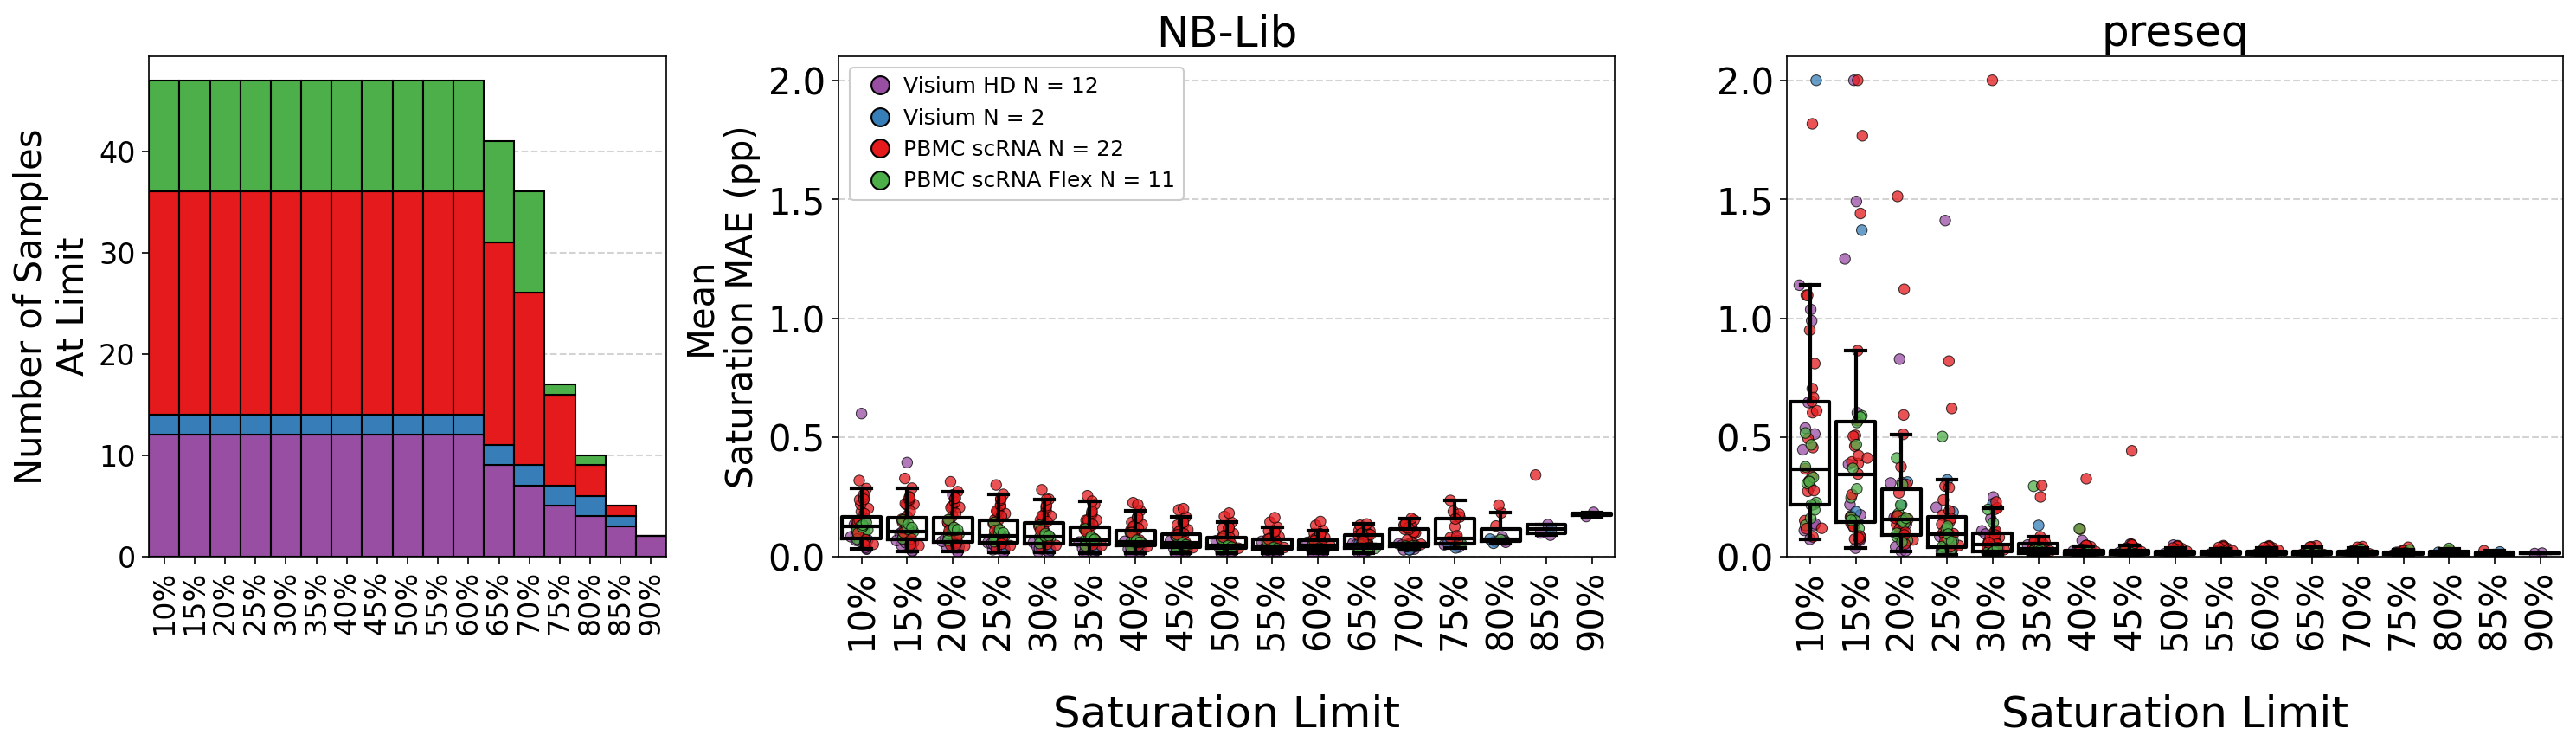

In [5]:
from collections import Counter
from matplotlib.lines import Line2D
lmap = {
    'PBMC_scrna':'PBMC scRNA',
    'PBMC_scrna_flex':'PBMC scRNA Flex',
    'visium_hd':'Visium HD',
    'visium':'Visium',
}

fig, txs = pl.figax(1, 3, w=8, h=5, width_ratios=[2,3,3])
fig.subplots_adjust(wspace=0.25)
axs = txs[1:]
lcount = Counter()
seen = set()
for (c, d) in psummaries:
    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]
    lcount[(cc['group'])] += 1

sc = Counter()

lboxes = {}
lfracs = {}
pboxes = {}
pfracs = {}

lcolors = {}
pcolors = {}

llabs = []

limits = {}
for (c, d) in psummaries:
    g = (
        d.groupby('limit')
         .agg(
             nb_lib_mae_mean = ('nb_lib_mae', 'mean'),
             #nb_lib_mae_frac = ('nb_lib_mae', lambda x: x.isna().mean()),
             preseq_mae_mean = ('preseq_mae', 'mean'),
             #preseq_mae_frac = ('preseq_mae', lambda x: x.isna().mean())
         )
    )

    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]
    lab = '_'
    if cc.group not in seen:
        lc = lcount[(cc['group'])]

        lab = f'{lmap[cc.group]} N = {lc}'
        llabs.append((lab, cc.group_color))
        
        seen.add(cc.group)


    for i, t in enumerate(g.itertuples()):
        limits[i] = t.Index
        if t.nb_lib_mae_mean > 2 or t.preseq_mae_mean > 2:
            print('outlier: ', c['sample'], t)
        lboxes.setdefault(i, []).append(min(2, t.nb_lib_mae_mean))
        #lfracs.setdefault(i, []).append(t.nb_lib_mae_frac)

        lcolors.setdefault(i, []).append(cc.group_color)
        
        
        pboxes.setdefault(i, []).append(min(2, t.preseq_mae_mean))
        #pfracs.setdefault(i, []).append(t.preseq_mae_frac)

        pcolors.setdefault(i, []).append(cc.group_color)
    #break
        


xt = []
xl = []
xlp = []
for k, l in sorted(limits.items()):
    pl.jitter_box(axs[0], k, lboxes[k], color=lcolors[k], s=35, edgecolor='k', lw=0.5, bwidth=0.85, alpha=0.75,
                 blw=2, mlw=2, wlw=2, plw=2)


    bot = 0
    lc = np.array(lcolors[k])
    for ll, c in llabs:
        ss = (lc == c).sum()
        txs[0].bar(k, ss, width=1, edgecolor='k', color=c, bottom=bot)
        bot += ss

    xt.append(k)


    
    xl.append(f'{l:.0f}%')

    pl.jitter_box(axs[1], k, pboxes[k], color=pcolors[k], s=35, edgecolor='k', lw=0.5, bwidth=0.85, alpha=0.75,
                 blw=2, mlw=2, wlw=2, plw=2)

    
    #pl.jitter_box(fxs[0], k, np.array(pfracs[k]) * 100, color=lcolors[k], s=35, edgecolor='0.5', lw=0.5, bwidth=0.85, alpha=0.75,
    #             blw=2, mlw=2, wlw=2, plw=2)

    xlp.append(f'{l:.0f}%')

txs[0].set_ylabel('Number of Samples\nAt Limit', fontsize=20)
txs[0].tick_params(axis='both', which='both', length=4)
txs[0].tick_params(axis='both', which='major', labelsize=16)
txs[0].set_xticks(xt)
txs[0].set_xticklabels(xl, rotation=90)
txs[0].set_xlim(-0.5, len(xt) - 0.5)
txs[0].grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
txs[0].set_axisbelow(True)


for a in axs.flatten():
    a.set_ylim(0, 2.1)
    a.tick_params(axis='both', which='both', length=4)
    a.tick_params(axis='both', which='major', labelsize=20)
    a.set_xticks(xt)
    
    a.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    a.set_axisbelow(True)

#fxs[0].tick_params(axis='both', which='both', length=4)
#fxs[0].tick_params(axis='both', which='major', labelsize=14)
#fxs[0].set_xticks(xt)

#fxs[0].grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
#fxs[0].set_axisbelow(True)
    
axs[0].set_xticklabels(xl, rotation=90)
axs[1].set_xticklabels(xlp, rotation=90)
#fxs[0].set_xticklabels(xlp, rotation=90)


axs[1].set_xlabel('Saturation Limit', fontsize=24, labelpad=24)
axs[0].set_xlabel('Saturation Limit', fontsize=24, labelpad=24)
#fxs[0].set_xlabel('Saturation Limit', fontsize=16, labelpad=2)



axs[0].set_ylabel('Mean\nSaturation MAE (pp)', fontsize=20)
axs[0].set_title('NB-Lib', fontsize=24)
axs[1].set_title('preseq', fontsize=24)
#fxs[0].set_title('preseq', fontsize=24)

handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=c, markeredgecolor='black',
           markersize=10, linestyle='None', label=l) 
        for l, c in llabs]




lgd = axs[0].legend(handles=handles,loc='upper left', frameon=True, framealpha=1, handletextpad=0.1, fontsize=12)
#fxs[0].set_ylabel('Failed Seeds (%)', fontsize=16)

#fxs[0].set_ylim(0, 85)
fig.savefig('../Figures/Figure 1D Saturation Limits.svg', bbox_inches='tight')

In [6]:
summaries = []
samples = set()

vdfs = []
pdfs = []
for i, c in cdf.iterrows():
    f1 = f'../{c["dataset"]}/{c["sample"]}/scdepth_limit_summary.txt'
    f2 = f'../{c["dataset"]}/{c["sample"]}/scdepth_preseq_summary.txt'

    bdf = df[df['sample'] == c['sample']].iloc[0]

    
    if not os.path.isfile(f1):
        continue

    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]

    d = pd.read_csv(f1, sep='\t')
    d2 = pd.read_csv(f2, sep='\t')
    d = d.merge(d2[['curve','limit','preseq_mae']], left_on = ['curve','limit'], right_on = ['curve', 'limit'])
    d['color'] = cc['group_color']
    dd = d[(d['limit'] < bdf.full_saturation)]
    if 'visium' in cc['group']:
        vdfs.append(dd[['sample','limit','ztnb_ks', 'nb_lib_err', 'preseq_mae', 'color']].copy())
    else:
        pdfs.append(dd[['sample','limit','ztnb_ks', 'nb_lib_err', 'preseq_mae', 'color']].copy())
    summaries.append((c, d))
vdfs = pd.concat(vdfs)
pdfs = pd.concat(pdfs)

,sample,limit,ztnb_ks,nb_lib_err,preseq_mae,color
75,CytAssist_11mm_FFPE_Human_Glioblastoma,10.0,0.000010,0.079073,41.524155,#377eb8
120,CytAssist_11mm_FFPE_Human_Glioblastoma,10.0,0.000022,0.101396,66.657768,#377eb8


,sample,limit,ztnb_ks,nb_lib_err,preseq_mae,color
20,Visium_HD_Human_Prostate_Cancer_FFPE,25.0,0.000053,0.05181,11.678236,#984ea3


,sample,limit,ztnb_ks,nb_lib_err,preseq_mae,color
96,SC3_v3_NextGem_SI_PBMC_10K,10.0,0.000015,0.246565,15.249382,#e41a1c


,sample,limit,ztnb_ks,nb_lib_err,preseq_mae,color
118,5k_pbmc_v3_nextgem,15.0,0.000145,0.200332,19.295826,#e41a1c
1,pbmc_10k_protein_v3,15.0,0.000163,0.309910,10.701923,#e41a1c
105,pbmc_1k_v3,15.0,0.000155,0.249696,14.484373,#e41a1c


,sample,limit,ztnb_ks,nb_lib_err,preseq_mae,color
137,SC3_v3_NextGem_DI_PBMC_10K,20.0,0.00014,0.152546,13.119385,#e41a1c


,sample,limit,ztnb_ks,nb_lib_err,preseq_mae,color
16,1k_PBMCs_TotalSeq_B_3p,30.0,0.001322,0.136408,87.10537,#e41a1c


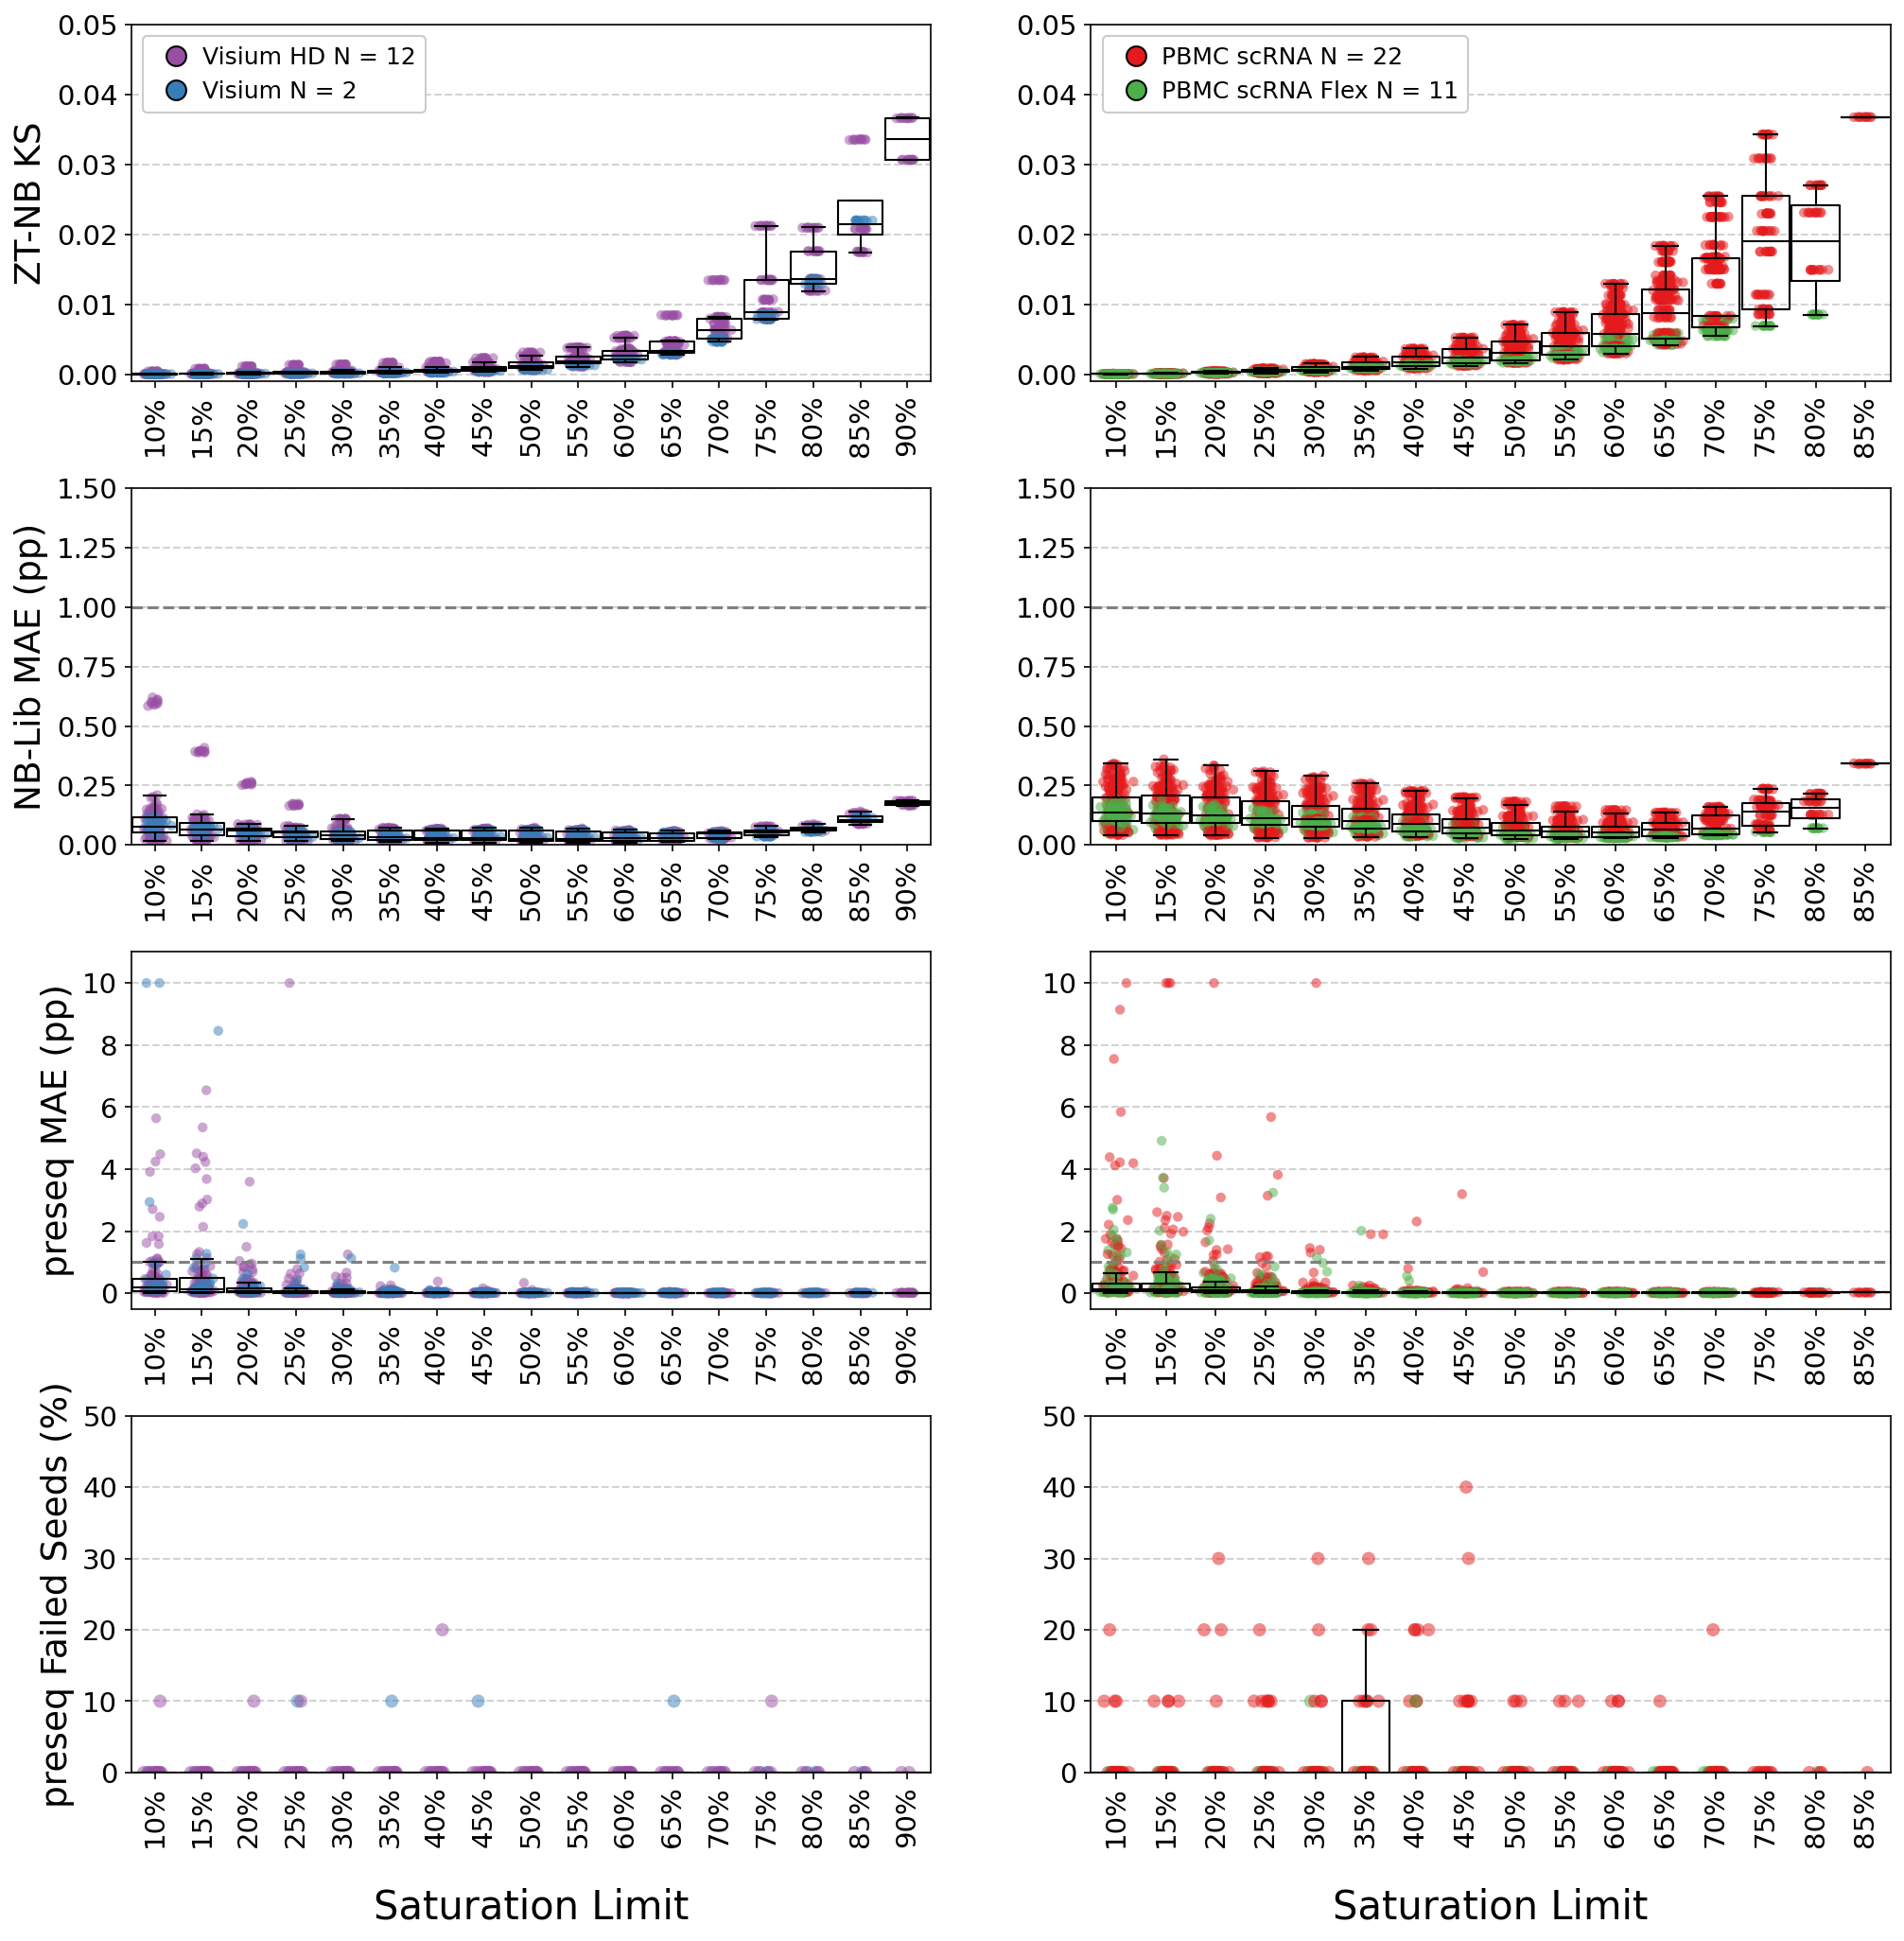

In [7]:
fig, raxs = pl.figax(4, 2, w=8, h=4)
fig.subplots_adjust(wspace=0.2, hspace=0.3)
axs = raxs.T
labels = ['Visium/Visium HD', 'PBMC']
for i, d in enumerate((vdfs, pdfs)):

    cols = ['ztnb_ks', 'nb_lib_err', 'preseq_mae']
    for idx, (l, d) in enumerate(d.groupby('limit')):
        for j, c in enumerate(cols):
            v = d[c].values
            sel = np.isfinite(v)
            v = v[sel]
            v[v>10] = 10
            pl.jitter_box(axs[i, j], idx, v, c=d['color'].values[sel], s=25, alpha=0.5)

        

        if np.any(d['preseq_mae'] > 10) or np.any(d['nb_lib_err'] > 10):
            display(d[(d['preseq_mae'] > 10) | (d['nb_lib_err'] > 10)])
        dd = d.groupby('sample').agg(bad=('preseq_mae', lambda x: x.isna().mean()),
                                       color=('color', 'first'))

        pl.jitter_box(axs[i, 3], idx, dd['bad']*100, c=dd['color'].values, s=45, alpha=0.5)

axs[0,1].set_ylim(-0.5, 11)
axs[0,2].set_ylim(-0.5, 11)
axs[1,1].set_ylim(-0.5, 11)
axs[1,2].set_ylim(-0.5, 11)



axs[0,1].axhline(1, ls='--', color='gray', zorder=1)
axs[0,2].axhline(1, ls='--', color='gray', zorder=1)
axs[1,1].axhline(1, ls='--', color='gray', zorder=1)
axs[1,2].axhline(1, ls='--', color='gray', zorder=1)
axs[0,1].set_ylim(0, 1.5)
axs[1,1].set_ylim(0, 1.5)

axs[0,3].set_ylim(0, 50)
axs[1,3].set_ylim(0, 50)

for (rx, N) in zip(axs, (17, 16)):
    for ax in rx:
        ax.set_xticks(np.arange(N))
        lims = [f'{x}%' for x in (np.arange(0, N) + 2) * 5]
        ax.set_xticklabels(lims, rotation=90)

axs[0,0].set_ylabel('ZT-NB KS', fontsize=18)
axs[0,1].set_ylabel('NB-Lib MAE (pp)', fontsize=18)
axs[0,2].set_ylabel('preseq MAE (pp)', fontsize=18)
axs[0,3].set_ylabel('preseq Failed Seeds (%)', fontsize=18)


lgd = axs[0,0].legend(handles=handles[:2],loc='upper left', frameon=True, framealpha=1, handletextpad=0.1, fontsize=12)
lgd = axs[1,0].legend(handles=handles[2:],loc='upper left', frameon=True, framealpha=1, handletextpad=0.1, fontsize=12)

for ax in axs.flatten():
    ax.tick_params(axis='both', which='major', labelsize=14,)
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
    
for ax in raxs[-1]:
    ax.set_xlabel('Saturation Limit', fontsize=20, labelpad=20)


axs[0,0].set_ylim(-0.001, 0.050)
axs[1,0].set_ylim(-0.001, 0.050)



fig.savefig('../Figures/Figure S1 Limits Full With Seeds.svg', bbox_inches='tight')


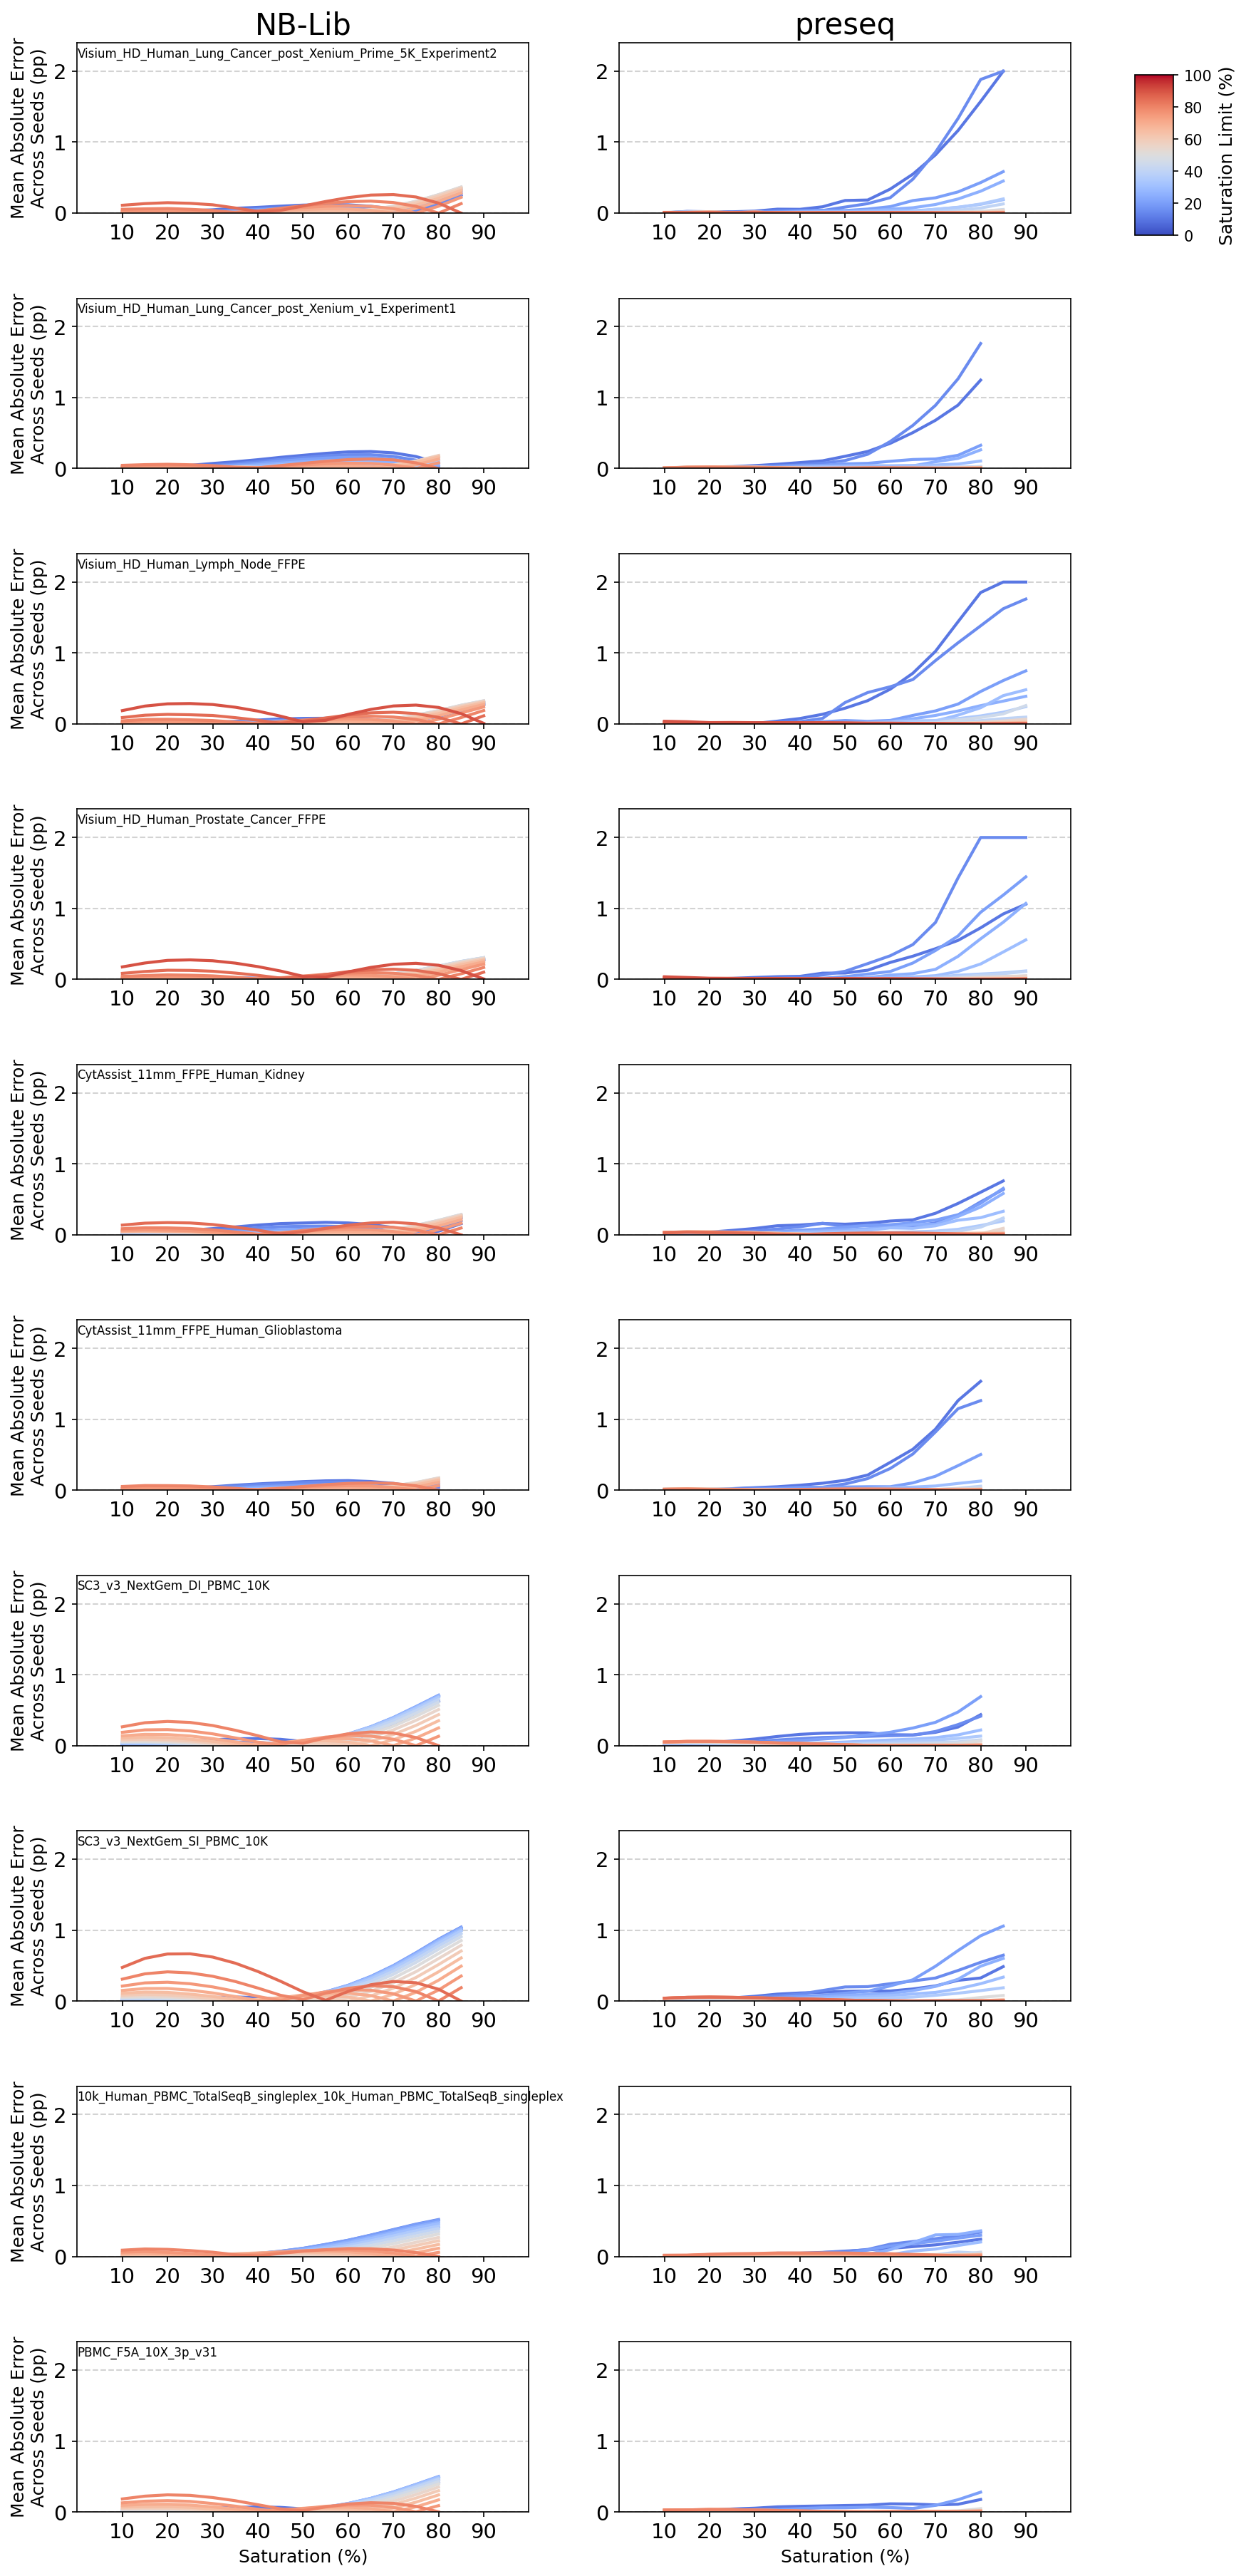

In [8]:
fig, axs = pl.figax(10, 2, w=6, h=3)
fig.subplots_adjust(hspace=0.5)
idx = 0
samps = []
for i, c in cdf.iterrows():
    f1 = f'../{c["dataset"]}/{c["sample"]}/scdepth_limit_summary.txt'
    f2 = f'../{c["dataset"]}/{c["sample"]}/scdepth_limit_curves.txt'
    f3 = f'../{c["dataset"]}/{c["sample"]}/scdepth_preseq_curves.txt'


    bdf = df[df['sample'] == c['sample']].iloc[0]
    if bdf.full_saturation < 80:
        continue
    
    if not os.path.isfile(f1):
        continue

    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]

    d = pd.read_csv(f1, sep='\t')
    d2 = pd.read_csv(f2, sep='\t')
    d3 = pd.read_csv(f3, sep='\t')

    lims = np.sort(d['limit'].unique())
    samps.append(c['sample'])
    for i, l in enumerate(lims):
        errs = []
        errsp = []
        for j in range(10):
            ts = d2[f'curve_{j}_saturation'].to_numpy(float)
            pred = d3[f'curve_{j}_{i}_nb_lib'].to_numpy(float)
            pred2 = d3[f'curve_{j}_{i}_preseq'].to_numpy(float)

            errs.append(np.abs(ts - pred))
            errsp.append(np.abs(ts - pred2))


        err = np.median(errs, axis=0)
        err2 = np.median(errsp, axis=0)

        axs[idx, 0].plot(lims, err, lw=2, color=plt.cm.coolwarm(l/100))
        err2[err2 > 2] = 2
        axs[idx, 1].plot(lims, err2, lw=2, color=plt.cm.coolwarm(l/100))

    idx += 1
for ax in axs.flatten():
    ax.set_ylim(0, 2.4)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(10, 95, 10))
    ax.tick_params(axis='both', which='major', labelsize=14,)
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
axs[0,0].set_title('NB-Lib', fontsize=20)
axs[0,1].set_title('preseq', fontsize=20)
for ax in axs[-1]:
    ax.set_xlabel('Saturation (%)', fontsize=12)
for samp, ax in zip(samps, axs[:,0]):
    ax.set_ylabel('Mean Absolute Error\nAcross Seeds (pp)', fontsize=12)
    ax.text(0.02, 2.2, samp, fontsize=8)

import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=100)
cmap = mpl.cm.coolwarm
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

cbax = fig.add_axes([0.95, 0.82, 0.03, 0.05])
cbar = fig.colorbar(sm,cax=cbax)
cbar.set_label('Saturation Limit (%)', fontsize=12)
fig.savefig('../Figures/Figure S4 Limits With Positions.svg', bbox_inches='tight')
    